#Final capstone project
##module 2-Machine learning pipeline
###Titanic Survival prediction
**objective**Build and evaluate multiple machine learning models to predict passengeer survival.

In [12]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

##step 1:Load feature Engineered Dataset

In [13]:
df=pd.read_csv("titanic_feature_engineered.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (889, 16)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1


##step 2:Select Features and Target

In [14]:
features=[
    "pclass",
    "sex",
    "age",
    "fare",
    "embarked",
    "family_size",
    "is_alone"
]
X=df[features]
y=df["survived"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (889, 7)
Target Shape: (889,)


In [15]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (711, 7)
Testing Samples: (178, 7)


##step 4: Create Preprocessing Pipeline

In [16]:
numeric_features=[
    "age",
    "fare",
    "family_size"
]
numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_features=[
    "sex",
    "embarked",
    "pclass",
    "is_alone"
]
categorical_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer([
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)
print("Preprocessor Created Successfully")

Preprocessor Created Successfully


##step 5:Logistic Regression Pipeline

In [17]:
logistic_pipeline=Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(random_state=42, max_iter=1000)
    )
])
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


##step 6:Evaluate Logistic Regression 

In [18]:
y_pred=logistic_pipeline.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Accuracy :", round(accuracy,3))
print("Precision :", round(precision,3))
print("Recall :", round(recall,3))
print("F1 Score :", round(f1,3))

Accuracy : 0.82
Precision : 0.8
Recall : 0.706
F1 Score : 0.75


###Interpretation 
Accuracy measures overall prediction performance.
Precision measures correct positive predictions.
Recall  measures how many survivors are correctly identified.
F1-score balances precision and recall.

##step 7:Decision Tree Classifier
Decision Tree is a supervised machine learning algorithm that make predictions using a tree-like structure of decisions.

In [19]:
#Decision Tree Pipeline
decision_tree_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeClassifier(random_state=42))
])
decision_tree_pipeline.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [20]:
#predictions
dt_predictions=decision_tree_pipeline.predict(X_test)

#Evaluation
dt_accuracy=accuracy_score(y_test, dt_predictions)
dt_precision=precision_score(y_test, dt_predictions)
dt_recall=recall_score(y_test,dt_predictions)
dt_f1=f1_score(y_test,dt_predictions)

print("Decision Tree Accuracy :", round(dt_accuracy,3))
print("Decision Tree Precision :", round(dt_precision,3))
print("Decision Tree Recall :", round(dt_recall,3))
print("Decision Tree F1 Score :", round(dt_f1,3))

Decision Tree Accuracy : 0.77
Decision Tree Precision : 0.701
Decision Tree Recall : 0.691
Decision Tree F1 Score : 0.696


###Interpretation
-Decision Tree learns decision rules from the training dataset.
-It is easy to understand and visualize.
-A very deep tree may overfit the training data.

##step 8: Random Forest Classifier
Random Forest Combines multiple decision trees and produces a more stable prediction.

In [21]:
#Random Forest Pipeline
random_forest_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])
random_forest_pipeline.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [22]:
rf_predictions=random_forest_pipeline.predict(X_test)
rf_accuracy=accuracy_score(y_test,rf_predictions)
rf_precision=precision_score(y_test,rf_predictions)
rf_recall=recall_score(y_test,rf_predictions)
rf_f1=f1_score(y_test,rf_predictions)

print("Random Forest Accuracy :", round(rf_accuracy,3))
print("Random Forest Precision :", round(rf_precision,3))
print("Random Forest Recall :", round(rf_recall,3))
print("Random Forest F1 Score :", round(rf_f1,3))

Random Forest Accuracy : 0.781
Random Forest Precision : 0.723
Random Forest Recall : 0.691
Random Forest F1 Score : 0.707


###Interpretation
-Random Forest usually performs better than a single Decision Tree.
-It combines predictions from many trees.
-This improves model stability and reduces overfitting.

##step 9:Model Comparision
The performance of Logistic Regression, Decision Tree, and Random Forest is compared using evaluation metrics.

In [23]:
comparision_df=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ]
})
comparision_df=comparision_df.round(3)
display(comparision_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820,0.800,0.706,0.750
1,Decision Tree,0.770,0.701,0.691,0.696
2,Random Forest,0.781,0.723,0.691,0.707


##step 10:Confusion Matrix
A confusion matrix shows how many predictions are correct and incorrect for each class.

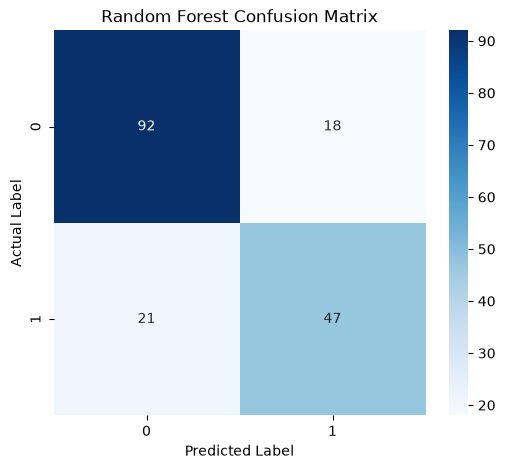

In [24]:
#Confusion Matrix for Random Forest
cm=confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

###Interpretation
-The confusion matrix summarizes correct and incorrect classifications.
-Higher values on the diagonal indicate better model performance.
-Off-diagonal values represent prediction errors.

##step 11:ROC Curve AUC Score
ROC Curve evaluates model performance across different classification thresholds.

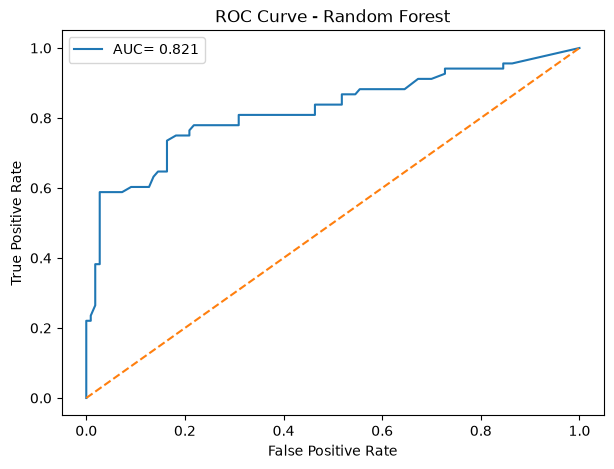

AUC Score: 0.821


In [25]:
from sklearn.metrics import roc_curve,roc_auc_score
#probability predictions
rf_probabilities=random_forest_pipeline.predict_proba(X_test)[:,1]

#ROC values
fpr, tpr, thresholds=roc_curve(y_test,rf_probabilities)
auc_score=roc_auc_score(y_test,rf_probabilities)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC= {auc_score:.3f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
print("AUC Score:", round(auc_score,3))

###Interpretation
-ROC Curve measures classification performance at multiple thresholds.
-A higher AUC score indicates better discrimination between classes.
-Random Forest generally produces a strong ROC curve for this dataset.

##step 12: SMOTE for class Balancing.
SMOTE generates synthetic samples for the minority class to balance the training dataset.

In [26]:
from imblearn.over_sampling import SMOTE
#Apply preprocessing first
X_train_processed=preprocessor.fit_transform(X_train)
smote=SMOTE(random_state=42)
X_smote, y_smote=smote.fit_resample(
    X_train_processed,
    y_train
)
print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())

Before SMOTE: survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


###Interpretation
-Before SMOTE, the dataset contains class imbalance.
-SMOTE balances both classes by generating synthetic samples.
-Balanced data can improve recall for the minority class.

##step 13:Hyperparameter Tuning using GridSearchCV
GridSearchCV searches multiple parameter combinations and selects the best-performing model.

In [27]:
from sklearn.model_selection import GridSearchCV
parameter_grid={
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10, None]
}
grid_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    (
        "model",
        RandomForestClassifier(random_state=42)
    )
])
grid_search=GridSearchCV(
    estimator=grid_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best Accuracy:", round(grid_search.best_score_,3))


Best Parameters:
{'model__max_depth': 5, 'model__n_estimators': 50}
Best Accuracy: 0.819


###Interpretation
-GridSearchCV evaluates several parameter combinations.
-The model with the highest validation accuracy is selected.
-The best parameters are used for the final pipeline.

##step 14: Save the Best Machine Learning Pipeline
The trained pipeline is saved so it can be reused without retraining.

In [29]:
import joblib
joblib.dump(
    grid_search.best_estimator_,
    "best_pipeline.joblib"
)
print("Best pipeline saved successfully!")

Best pipeline saved successfully!


##step 15:Load Saved Pipeline and Predict

In [30]:
loaded_model=joblib.load("best_pipeline.joblib")
sample_predictions=loaded_model.predict(X_test.head())
print("Sample Predictions:")
print(sample_predictions)

Sample Predictions:
[0 0 0 0 0]


###Interpretation 
The saved machine learning pipeline was loaded successfully using Joblib.The model generated predictions for the first five passengers in the test dataset.In this sample,all five predictions are 0,which indicvates that the model predicted these passengers did not survive.
